In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

### EX1

1\.a Make a new directory called `students` in your home. Download a csv file with the list of students of this lab from [here](https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv) (use the `wget` command) and copy that to `students`. First check whether the file is already there

In [2]:
!mkdir -p students

In [3]:
%cd ~/students

/Users/amirmohammadsaiedisaber/students


In [3]:
!wget -O LCP_students.csv "https://www.dropbox.com/scl/fi/bxv17nrbrl83vw6qrkiu9/LCP_22-23_students.csv?rlkey=47fakvatrtif3q3qw4q97p5b7&e=1"

--2026-06-08 22:35:22--  https://www.dropbox.com/scl/fi/bxv17nrbrl83vw6qrkiu9/LCP_22-23_students.csv?rlkey=47fakvatrtif3q3qw4q97p5b7&e=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3777d0c1d1b1223f878a2a39b5.dl.dropboxusercontent.com/cd/0/inline/DCDgbbZFdp74QWqmik_SbY-PqwSH8eNBQyStmvqfZNP4xPRNxf0zn7FtK8XuMHTgLcbFrQN4bzGsw-iiC98kvr4ktbCQnonX05D6NPatGxKLfHvWiYVBBkIFjevA1FowNUo/file# [following]
--2026-06-08 22:35:23--  https://uc3777d0c1d1b1223f878a2a39b5.dl.dropboxusercontent.com/cd/0/inline/DCDgbbZFdp74QWqmik_SbY-PqwSH8eNBQyStmvqfZNP4xPRNxf0zn7FtK8XuMHTgLcbFrQN4bzGsw-iiC98kvr4ktbCQnonX05D6NPatGxKLfHvWiYVBBkIFjevA1FowNUo/file
Resolving uc3777d0c1d1b1223f878a2a39b5.dl.dropboxusercontent.com (uc3777d0c1d1b1223f878a2a39b5.dl.dropboxusercontent.com)... 162.125.69.15
Connecting to uc3777d0c1d1b1223f878a2a39b5.dl.dropboxusercon

1\.b Make two new files, one containing the students belonging to PoD, the other to Physics.

In [4]:
!grep ',PoD' LCP_students.csv > PoD_students.csv

In [5]:
!grep ',Physics' LCP_students.csv > Physics_students.csv

1\.c For each letter of the alphabet, count the number of students whose surname starts with that letter. 

In [9]:
%%bash

tail -n+2 LCP_students.csv | cut -f1 | cut -c1 | sort | uniq -c

   2 A
  13 B
   3 C
   6 D
   1 E
   3 F
   4 G
   1 H
   1 I
   1 J
   1 K
   3 L
   7 M
   6 P
   2 R
   7 S
   2 T
   3 V
   2 W
   5 Z


1\.d Find out which is the letter with most counts.

In [11]:
%%bash

tail -n+2 LCP_students.csv | cut -f1 | cut -c1 | sort | uniq -c | sort -nr | head -1 

  13 B


1\.e Assume an obvious numbering of the students in the file (first line is 1, second line is 2, etc.), group students "modulo 18", i.e. 1,19,37,.. 2,20,38,.. etc. and put each group in a separate file  

In [8]:
%%bash

tail -n+2 LCP_students.csv | awk '{g=(NR-1)%18+1 ; print >> ("group_" g ".csv")}' 

### EX2

2.a Make a copy of the file `data.csv` removing the metadata and the commas between numbers; call it `data.txt`

In [4]:
!touch data.csv

In [5]:
%%writefile data.csv
# get the line with "sensor"
grep "sensor" data.csv

# get the metadata
grep "^#" data.csv 

# get the data payload (all lines w/o "#" at the beginning)
grep -v "^#" data.csv 

# count the number of lines in the data payload
grep -c -v "^#" data.csv 

# look for the sensor by name
grep "X[a-z].v*" data.csv 
# searches are case sensistive:
grep "X[A-Z].v*" data.csv 

# use cut to get part of the line, in this case the starting time
grep "started" data.csv | cut -f7 -d " "

# substitute Oct with Nov
sed -e "s/Oct/Nov/" data.csv

# Add ".0" to all single digit number
sed -e "s/\b[0-9]\{1\}\b/&.0/" data.csv 

Overwriting data.csv


In [6]:
!grep -v "^#" data.csv | tr ',' ' ' > data.txt

2\.b How many even numbers are there?

In [7]:
%%bash

awk '{for(i=1;i<=NF;i++) if($i%2==0) c++} END {print c}' data.txt

38


2\.c Distinguish the entries on the basis of `sqrt(X^2 + Y^2 + Z^2)` is greater or smaller than `100*sqrt(3)/2`. Count the entries of each of the two groups

In [18]:
%%bash

awk '{T=100*sqrt(3)/2} {r=sqrt($1*$1+$2*$2+$3*$3); if(r>T) a++; else b++} END {print a,b}' data.txt

 16


2\.d Make `n` copies of data.txt (with `n` an input parameter of the script), where the i-th copy has all the numbers divided by i (with `1<=i<=n`).

In [ ]:
%%bash
n=8
for ((i=1;i<=n;i++)); do
    awk -v d=$i '{for(j=1;j<=NF;j++) $j=$j/d; print}' data.txt > data_$i.txt
done

# loop i = 1..n                  -> one output file per divisor
# -v d=$i                        -> send i into awk as d
# $j = $j/d  (for every field)   -> overwrite each number with number/d
# print                          -> awk reprints the whole line for you (spaces auto)


In [ ]:
%%bash

n=11
for ((i=1;i<=n;i++)); do
 awk -v d = $i '{for(j=1;j<=NF;j++) $j=$j/d; print}'  data.txt > data_$i.txt
done

### NUMPY

 Find the outer product of the following two vecotrs

```python
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
```

Do this in the following ways:

   * Using the function outer in numpy
   * Using a nested for loop or list comprehension
   * Using numpy broadcasting operatoins

In [13]:
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])

In [15]:
cross = np.outer(u,v)
cross

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

In [36]:
l=[]
for i in range(4):
    for j in range(4):
        l.append(u[i]*v[j])
q = np.array(l)
print(q.reshape(4,4))

[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]


In [41]:
np.array([u[i]*v[j] for i in range(4) for j in range(4)]).reshape(4,4)

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

In [45]:
u[:,None] * v[None,:] # broadcasting 

array([[ 2,  4,  6,  8],
       [ 6, 12, 18, 24],
       [10, 20, 30, 40],
       [14, 28, 42, 56]])

Create a 10 by 6 matrix of random uniform numbers. Set all rows with any entry less than 0.1 to be zero

Hint: Use the following numpy functions - np.random.random, np.any as well as Boolean indexing and the axis argument.

In [76]:
y = np.random.random((10,6))
print("before manipulation = " ,y,'\n')
k = np.any(y < 0.1, axis=1)
y[k] = 0
print("after manipulation = " ,y)

before manipulation =  [[0.00270321 0.64719665 0.60039224 0.58873961 0.96277032 0.01687167]
 [0.69648243 0.81367865 0.5098072  0.33396487 0.79084016 0.09724293]
 [0.44203564 0.51995237 0.69395641 0.09088573 0.2277595  0.41030156]
 [0.62329467 0.88696078 0.61882617 0.13346147 0.98058013 0.87178573]
 [0.50272076 0.92234798 0.54138079 0.92330607 0.82989737 0.96828641]
 [0.91978281 0.03603382 0.174772   0.38913468 0.9521427  0.30002892]
 [0.16046764 0.88630467 0.44639442 0.90787559 0.16023047 0.66111751]
 [0.44026375 0.07648677 0.69646314 0.24739876 0.03961552 0.0599443 ]
 [0.06107854 0.90773296 0.73988392 0.89806236 0.67258231 0.52893993]
 [0.30444636 0.99796225 0.36218906 0.47064895 0.37824517 0.97952693]] 

after manipulation =  [[0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.62329467 0.88696078 0.61882617 0.13346147 0.9805801

 Use np.linspace to create an array of 100 numbers between 0 and 2π (includsive).

  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

In [83]:
p = np.linspace(0,2*np.pi,100)
p

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [102]:
p[::10]

array([0.        , 0.63466518, 1.26933037, 1.90399555, 2.53866073,
       3.17332591, 3.8079911 , 4.44265628, 5.07732146, 5.71198664])

In [84]:
p[::-1]

array([6.28318531, 6.21971879, 6.15625227, 6.09278575, 6.02931923,
       5.96585272, 5.9023862 , 5.83891968, 5.77545316, 5.71198664,
       5.64852012, 5.58505361, 5.52158709, 5.45812057, 5.39465405,
       5.33118753, 5.26772102, 5.2042545 , 5.14078798, 5.07732146,
       5.01385494, 4.95038842, 4.88692191, 4.82345539, 4.75998887,
       4.69652235, 4.63305583, 4.56958931, 4.5061228 , 4.44265628,
       4.37918976, 4.31572324, 4.25225672, 4.1887902 , 4.12532369,
       4.06185717, 3.99839065, 3.93492413, 3.87145761, 3.8079911 ,
       3.74452458, 3.68105806, 3.61759154, 3.55412502, 3.4906585 ,
       3.42719199, 3.36372547, 3.30025895, 3.23679243, 3.17332591,
       3.10985939, 3.04639288, 2.98292636, 2.91945984, 2.85599332,
       2.7925268 , 2.72906028, 2.66559377, 2.60212725, 2.53866073,
       2.47519421, 2.41172769, 2.34826118, 2.28479466, 2.22132814,
       2.15786162, 2.0943951 , 2.03092858, 1.96746207, 1.90399555,
       1.84052903, 1.77706251, 1.71359599, 1.65012947, 1.58666

In [103]:
mask = np.abs(np.sin(p) - np.cos(p)) < 0.1
p[mask]

array([0.76159822, 0.82506474, 3.87145761, 3.93492413])

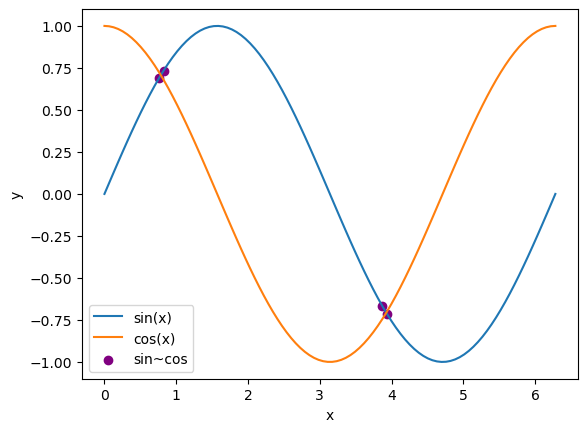

In [113]:
plt.plot(p,np.sin(p), label="sin(x)"); plt.plot(p,np.cos(p),label="cos(x)")
plt.scatter(p[mask], np.sin(p)[mask], color="purple",label= "sin~cos")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

Create a matrix that shows the 10 by 10 multiplication table.

 * Find the trace of the matrix
 * Extract the anto-diagonal (this should be ```array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10])```)
 * Extract the diagnoal offset by 1 upwards (this should be ```array([ 2,  6, 12, 20, 30, 42, 56, 72, 90])```)

In [16]:
t = np.outer(np.arange(1,10+1),np.arange(1,10+1)) ; print(t,'\n')
tr = np.trace(t); int(tr)

[[  1   2   3   4   5   6   7   8   9  10]
 [  2   4   6   8  10  12  14  16  18  20]
 [  3   6   9  12  15  18  21  24  27  30]
 [  4   8  12  16  20  24  28  32  36  40]
 [  5  10  15  20  25  30  35  40  45  50]
 [  6  12  18  24  30  36  42  48  54  60]
 [  7  14  21  28  35  42  49  56  63  70]
 [  8  16  24  32  40  48  56  64  72  80]
 [  9  18  27  36  45  54  63  72  81  90]
 [ 10  20  30  40  50  60  70  80  90 100]] 



385

In [20]:
tt = t[::-1]
np.diag(tt)

array([10, 18, 24, 28, 30, 30, 28, 24, 18, 10])

In [24]:
np.diag(t,k=1)

array([ 2,  6, 12, 20, 30, 42, 56, 72, 90])

Use broadcasting to create a grid of distances

Route 66 crosses the following cities in the US: Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles The corresponding positions in miles are: 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448

Construct a 2D grid of distances among each city along Route 66
Convert that in km (those savages...)

In [3]:
mile=np.array([0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448])

In [4]:
zz = np.abs(mile[None,:] - mile[:,None])
zz

array([[   0,  198,  303,  736,  871, 1175, 1475, 1544, 1913, 2448],
       [ 198,    0,  105,  538,  673,  977, 1277, 1346, 1715, 2250],
       [ 303,  105,    0,  433,  568,  872, 1172, 1241, 1610, 2145],
       [ 736,  538,  433,    0,  135,  439,  739,  808, 1177, 1712],
       [ 871,  673,  568,  135,    0,  304,  604,  673, 1042, 1577],
       [1175,  977,  872,  439,  304,    0,  300,  369,  738, 1273],
       [1475, 1277, 1172,  739,  604,  300,    0,   69,  438,  973],
       [1544, 1346, 1241,  808,  673,  369,   69,    0,  369,  904],
       [1913, 1715, 1610, 1177, 1042,  738,  438,  369,    0,  535],
       [2448, 2250, 2145, 1712, 1577, 1273,  973,  904,  535,    0]])

In [6]:
km = zz*1.609
km.astype(int)

array([[   0,  318,  487, 1184, 1401, 1890, 2373, 2484, 3078, 3938],
       [ 318,    0,  168,  865, 1082, 1571, 2054, 2165, 2759, 3620],
       [ 487,  168,    0,  696,  913, 1403, 1885, 1996, 2590, 3451],
       [1184,  865,  696,    0,  217,  706, 1189, 1300, 1893, 2754],
       [1401, 1082,  913,  217,    0,  489,  971, 1082, 1676, 2537],
       [1890, 1571, 1403,  706,  489,    0,  482,  593, 1187, 2048],
       [2373, 2054, 1885, 1189,  971,  482,    0,  111,  704, 1565],
       [2484, 2165, 1996, 1300, 1082,  593,  111,    0,  593, 1454],
       [3078, 2759, 2590, 1893, 1676, 1187,  704,  593,    0,  860],
       [3938, 3620, 3451, 2754, 2537, 2048, 1565, 1454,  860,    0]])

 Prime numbers sieve: compute the prime numbers in the 0-N (N=99 to start with) range with a sieve (mask).
  * Constract a shape (100,) boolean array, the mask
  * Identify the multiples of each number starting from 2 and set accordingly the corresponding mask element
  * Apply the mask to obtain an array of ordered prime numbers
  * Check the performances (timeit); how does it scale with N?
  * Implement the optimization suggested in the [sieve of Eratosthenes](https://en.wikipedia.org/wiki/Sieve_of_Eratosthenes)

In [44]:
def sieve(n):
    msk = np.ones(n + 1, dtype=bool)
    msk[:2] = 0

    for i in range(2, n + 1):
        msk[2*i::i] = 0

    return np.nonzero(msk)[0]

In [37]:
def opt(n):
    mk = np.ones(n+1,dtype=bool)
    mk[:2]=0

    for i in range(2,int(np.sqrt(n)+1)):
        mk[i*i::i] = 0
            
    return np.nonzero(mk)[0]

In [40]:
%timeit sieve(1000)

161 μs ± 2.09 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
%timeit opt(1000)

7.57 μs ± 116 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Diffusion using random walk

Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a raw and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each raw")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

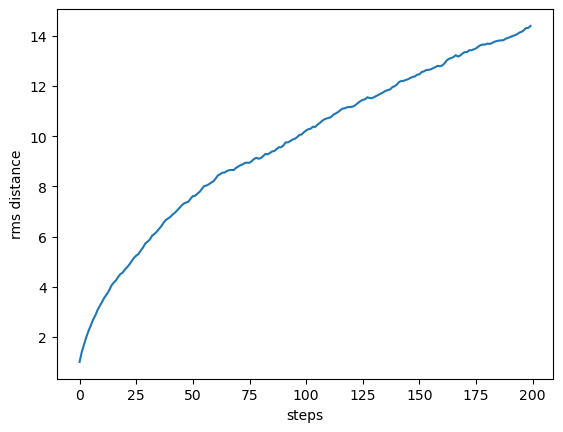

In [14]:
walkers, steps = 1000, 200
moves = np.random.choice([-1,1], size=(walkers,steps))
pos = moves.cumsum(axis=1)
rms = np.sqrt((pos**2).mean(axis=0))
plt.plot(rms); plt.xlabel("steps"); plt.ylabel("rms distance")
plt.show()

Analyze a data file

Download the population of hares, lynxes and carrots at the beginning of the last century.

! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
Check the content by looking within the file

Load the data (use an appropriate numpy method) into a 2D array

Create arrays out of the columns, the arrays being (in order): year, hares, lynxes, carrots

Plot the 3 populations over the years

Compute the main statistical properties of the dataset (mean, std, correlations, etc.)

Which species has the highest population each year?

Do you feel there is some evident correlation here? Studies tend to believe so.

In [17]:
!wget -O population.txt "https://www.dropbox.com/scl/fi/qnkkslc4wt15bziu8c8do/populations.txt?rlkey=mxkget6g834glvegmf12yl2op&e=1"

--2026-06-10 00:21:30--  https://www.dropbox.com/scl/fi/qnkkslc4wt15bziu8c8do/populations.txt?rlkey=mxkget6g834glvegmf12yl2op&e=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc94cbf4364ac3a82ed660624e7f.dl.dropboxusercontent.com/cd/0/inline/DCFUGy5T-ks_FgA9AEvaJrtQH3h795hESHiX8PFKgxKzo7HmYvNkh-k_gx3vbQ9BBaLsHui-xzaPEMbdIQ3Ruw8TCfXE5AJ-T_PCkR2GlSyNUlkUZGORxMLiaIma_3KxIpo/file# [following]
--2026-06-10 00:21:30--  https://uc94cbf4364ac3a82ed660624e7f.dl.dropboxusercontent.com/cd/0/inline/DCFUGy5T-ks_FgA9AEvaJrtQH3h795hESHiX8PFKgxKzo7HmYvNkh-k_gx3vbQ9BBaLsHui-xzaPEMbdIQ3Ruw8TCfXE5AJ-T_PCkR2GlSyNUlkUZGORxMLiaIma_3KxIpo/file
Resolving uc94cbf4364ac3a82ed660624e7f.dl.dropboxusercontent.com (uc94cbf4364ac3a82ed660624e7f.dl.dropboxusercontent.com)... 162.125.69.15
Connecting to uc94cbf4364ac3a82ed660624e7f.dl.dropboxusercontent.co

In [3]:
data = np.loadtxt("population.txt")

In [9]:
# 2. Make column arrays (order: year, hares, lynxes, carrots)
year, hares, lynxes, carrots = data.T # .T unpacks columns in one line

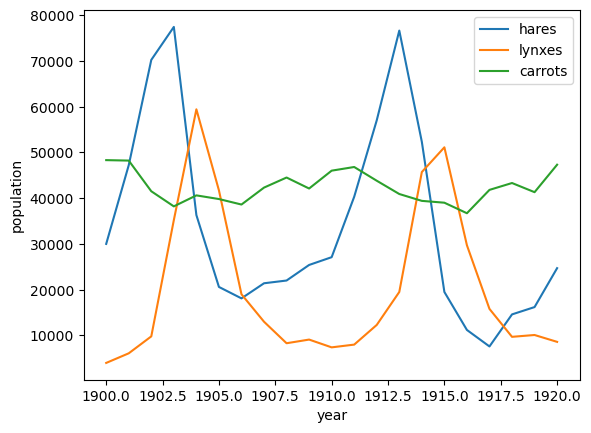

In [12]:
# 3. Plot the 3 populations
plt.plot(year, hares, label="hares")
plt.plot(year, lynxes, label="lynxes")
plt.plot(year, carrots, label="carrots")
plt.xlabel("year"); plt.ylabel("population")
plt.legend()
plt.show()

In [30]:
pops = data[:,1:]   # all rows, columns 1,2,3 (skip year)
print("Mean: ", pops.mean(axis=0))
print("std: ", pops.std(axis=0))
print("correlation", (np.corrcoef(pops.T))) # .T so each species is a row

Mean:  [34080.95238095 20166.66666667 42400.        ]
std:  [20897.90645809 16254.59153691  3322.50622558]
correlation [[ 1.          0.07189206 -0.01660378]
 [ 0.07189206  1.         -0.68057717]
 [-0.01660378 -0.68057717  1.        ]]


In [28]:
idx = np.argmax(pops,axis=1)           # axis=1 = across each row → index of max
species = ["hares","lynxes","carrots"]       # turn indices into names
winner = np.array(species)[idx] 
for w,y in zip(winner,year):
    print(int(y),":",w)

1900 : carrots
1901 : carrots
1902 : hares
1903 : hares
1904 : lynxes
1905 : lynxes
1906 : carrots
1907 : carrots
1908 : carrots
1909 : carrots
1910 : carrots
1911 : carrots
1912 : hares
1913 : hares
1914 : hares
1915 : lynxes
1916 : carrots
1917 : carrots
1918 : carrots
1919 : carrots
1920 : carrots


### Visualization

 **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


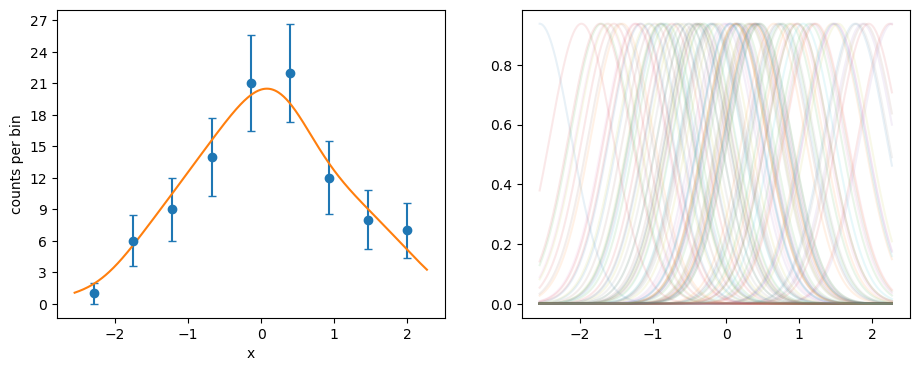

In [3]:
from scipy import stats
from matplotlib.ticker import MaxNLocator
N = 100; x = np.random.normal(0, 1, N)

counts, edges = np.histogram(x, bins="auto")       # "auto" = a meaningful # of bins
centers = 0.5*(edges[:-1] + edges[1:])
err = np.sqrt(counts)                              # poisson error = sqrt(count)

h = 1.06 * x.std() * N**(-1/5)                     
grid = np.linspace(edges[0], edges[-1], 400)
kde = np.sum([stats.norm.pdf(grid, xi, h) for xi in x], axis=0)   # one Gaussian per point
dx = grid[1] - grid[0]                                            # uniform grid spacing
kde *= np.sum(counts*np.diff(edges)) / (kde.sum()*dx)            # scale to histogram area

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(centers, counts, yerr=err, fmt='o', capsize=3)     # hist as points
ax[0].plot(grid, kde)
ax[0].set_xlabel("x"); ax[0].set_ylabel("counts per bin")         # proper labels
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))          # integer y ticks
for xi in x: ax[1].plot(grid, stats.norm.pdf(grid, xi, h), alpha=0.1)  # the kernels
plt.show()

**Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

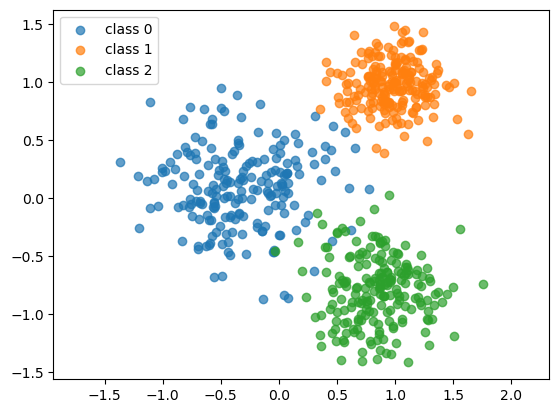

In [4]:
def make_data(ns, mus, sds):
    X, y = [], []
    for k, (n, mu, sd) in enumerate(zip(ns, mus, sds)):
        X.append(np.random.normal(mu, sd, (n, 2)))   # mu,sd length-2 -> per column
        y.append(np.full(n, k))
    return np.vstack(X), np.concatenate(y)

X, y = make_data([200,200,200], [(-0.3,0.1),(1,1),(0.8,-0.8)],
                                [(0.4,0.35),(0.25,0.2),(0.3,0.3)])
for k in np.unique(y):
    plt.scatter(X[y==k,0], X[y==k,1], label=f"class {k}", alpha=0.7)  # mask per class
plt.legend(); plt.axis("equal"); plt.show()

**Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

In [5]:
!wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy


--2026-06-16 10:23:36--  https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt [following]
--2026-06-16 10:23:36--  https://www.dropbox.com/scl/fi/cu0wjpyhyoy57w9yupavt/residuals_261.npy?rlkey=9rx6zjagfspm9mfc1jc3zejbt
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucf0eb5fd7a9c4072bc7b82acfa7.dl.dropboxusercontent.com/cd/0/inline/DCeKFG5m-xpSLemEio42NH_IECC5JaRbSehcgYmCzHh2EJAThjCMpYEx0PGG2R6xwZH0AIoSXCf4M7Q_poMp1ZncKSnlSIrC6uxrIx2sUzNTH_nYPeAibVJhW7CY_KaZjNM/file# [following]
--2026-06-16 10:23:37--  https://ucf0eb5fd7a9c4072bc7b82acfa7.dl.dropboxusercontent.com/cd/0/inline/DCeKFG5m-xpSLemEio42NH_IECC5JaRbS

/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


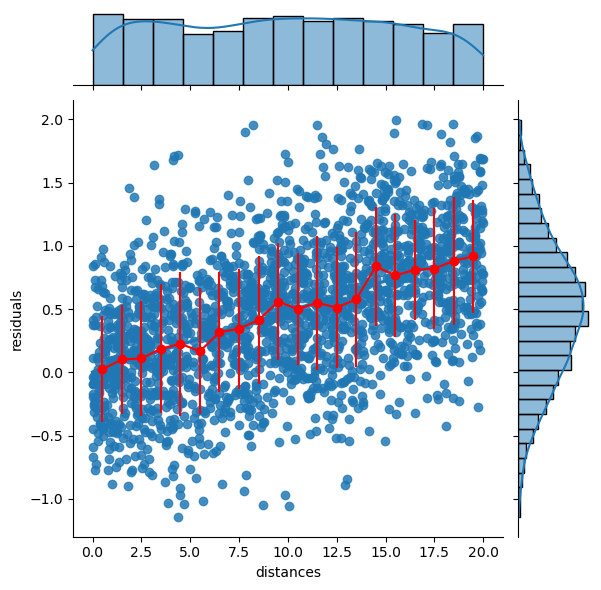

In [9]:
import pandas as pd, seaborn as sns
from scipy.stats import linregress

df = pd.DataFrame(np.load("residuals_261.npy", allow_pickle=True).item())
dist = np.random.uniform(0, 20, 2000)                       # synthetic stand-in
df = pd.DataFrame({"distances": dist,
                   "residuals": 0.05*dist + np.random.normal(0, 0.5, 2000)})
df = df[df["residuals"].abs() < 2]                          # clean: |residual| < 2
fit = linregress(df.distances, df.residuals)               # slope, intercept, r...
sns.jointplot(data=df, x="distances", y="residuals", kind="reg")  # seaborn regression

edges = np.linspace(0, 20, 21); centers = 0.5*(edges[:-1]+edges[1:])
b = np.digitize(df.distances, edges) - 1                    # digitize -> bin id
ymean = np.array([df.residuals[b==i].mean() for i in range(20)])
ystd  = np.array([df.residuals[b==i].std()  for i in range(20)])

plt.scatter(df.distances, df.residuals, s=5, alpha=0.2)
plt.errorbar(centers, ymean, yerr=ystd, fmt='o-', color="red")   # the profile
plt.show()

### Linear Algebra

**PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


In [10]:
from scipy import linalg as la
N = 1000
x1 = np.random.normal(0, 1, N)
x2 = x1 + np.random.normal(0, 3, N)
x3 = 2*x1 + x2
X = np.column_stack([x1, x2, x3])
Xc = X - X.mean(axis=0)                       # center each column

# route A: covariance
vals, vecs = la.eigh(np.cov(Xc, rowvar=False))   # eigh -> real, ascending
i = np.argsort(vals)[::-1]; vals, vecs = vals[i], vecs[:, i]   # sort descending
ratio = np.cumsum(vals)/vals.sum()
k99 = np.searchsorted(ratio, 0.99) + 1
print("explained:", ratio.round(3), "| keep", k99, "components")

# route B: SVD (same eigenvalues)
U, s, Vt = la.svd(Xc, full_matrices=False)
print("svd eigenvalues:", (s**2/(N-1)).round(3))

Xp = Xc @ vecs                               # data in PCA basis

explained: [0.931 1.    1.   ] | keep 2 components
svd eigenvalues: [26.515  1.978  0.   ]


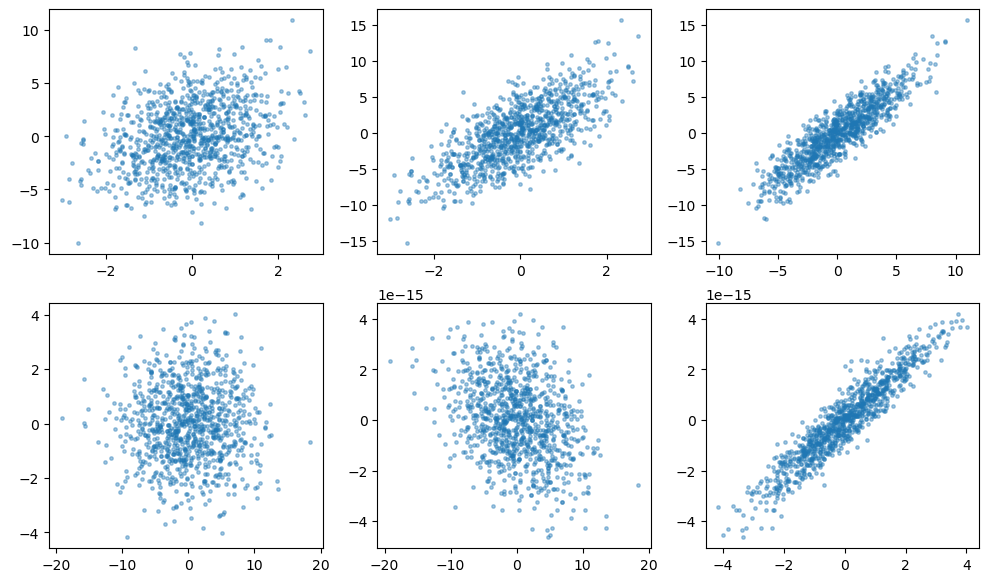

In [11]:
pairs = [(0,1), (0,2), (1,2)]
fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for j, (a, b) in enumerate(pairs):
    ax[0, j].scatter(X[:, a],  X[:, b],  s=6, alpha=0.4)   # original
    ax[1, j].scatter(Xp[:, a], Xp[:, b], s=6, alpha=0.4)   # PCA basis
plt.show()

**PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

keep 2 of 13 dims for 99% variance


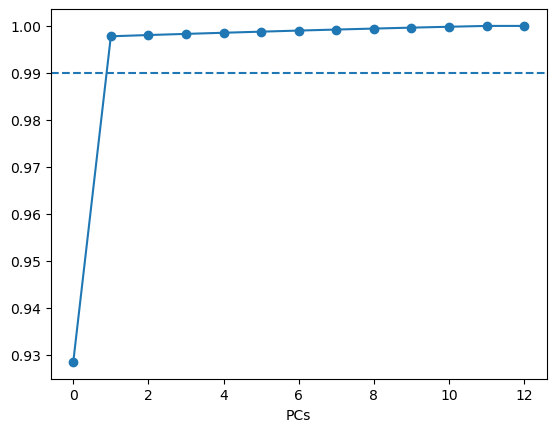

In [12]:
noise = np.random.normal(0, 4/50, (N, 10))      # std 50x smaller than signal
Xn = np.column_stack([X, noise])
Xnc = Xn - Xn.mean(axis=0)
vals, vecs = la.eigh(np.cov(Xnc, rowvar=False))
vals = np.sort(vals)[::-1]
ratio = np.cumsum(vals)/vals.sum()
print("keep", np.searchsorted(ratio, 0.99)+1, "of 13 dims for 99% variance")
plt.plot(ratio, 'o-'); plt.axhline(0.99, ls='--'); plt.xlabel("PCs"); plt.show()

### Algorithm

**Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```


In [15]:
from scipy.interpolate import UnivariateSpline

speeds = np.load("max-speeds.npy")
speeds = np.random.normal(25, 5, 21)               # synthetic stand-in
x = np.sort(speeds); n = len(x)
p = np.arange(1, n+1) / (n+1)                       # cumulative prob i/(N+1)
quantile = UnivariateSpline(p, x, s=0)             # spline = inverse CDF
print("50-year wind:", float(quantile(1 - 0.02)))  # upper 2% quantile

50-year wind: 37.07955949693789


**Curve fitting of temperature in Alaska**

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max: 17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.

* Define a function that can describe min and max temperatures.

* Fit this function to the data with scipy.optimize.curve_fit().

* Plot the result. Is the fit reasonable? If not, why?

* Is the time offset for min and max temperatures the same within the fit accuracy?

errors max: [0.56 0.1  0.4 ]


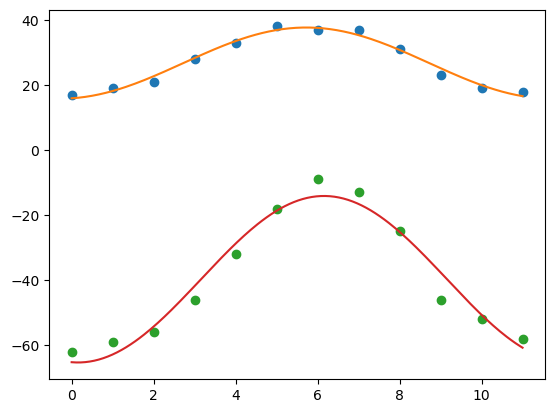

phase diff = 0.43 +/- 0.17  (consistent with 0 -> same offset)


In [18]:
from scipy.optimize import curve_fit
t = np.arange(12)
tmax = np.array([17,19,21,28,33,38,37,37,31,23,19,18])
tmin = np.array([-62,-59,-56,-46,-32,-18,-9,-13,-25,-46,-52,-58])

def model(t, A, phi, C):                            # cosine with 12-month period
    return A*np.cos(2*np.pi*(t - phi)/12) + C

pmax, cmax = curve_fit(model, t, tmax, p0=[10, 6, 25])
pmin, cmin = curve_fit(model, t, tmin, p0=[25, 6, -35])
print("errors max:", np.sqrt(np.diag(cmax)).round(2))   # err = sqrt(diag(cov))

s = np.linspace(0, 11, 200)
plt.plot(t, tmax, 'o'); plt.plot(s, model(s, *pmax))
plt.plot(t, tmin, 'o'); plt.plot(s, model(s, *pmin)); plt.show()

# same time offset for min & max?  compare phi within their errors
dphi = pmin[1] - pmax[1]; sphi = np.sqrt(cmin[1,1] + cmax[1,1])
print(f"phase diff = {dphi:.2f} +/- {sphi:.2f}  (consistent with 0 -> same offset)")

**2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


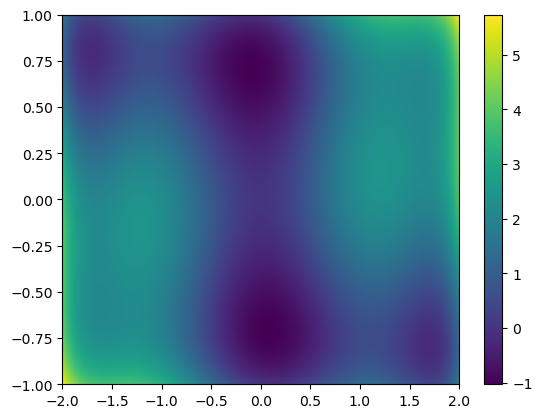

(-1.5, 0.5) -> [-1.704  0.796] f= -0.2155
(1.5, -0.5) -> [ 1.704 -0.796] f= -0.2155
(1.5, 0.5) -> [1.607 0.569] f= 2.1043
(-1.5, -0.5) -> [-1.607 -0.569] f= 2.1043
(0, 0) -> [0. 0.] f= 0.0


In [19]:
from scipy.optimize import minimize
def f(v):
    x, y = v
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (4*y**2 - 4)*y**2

X, Y = np.meshgrid(np.linspace(-2,2,400), np.linspace(-1,1,400))
plt.imshow(f((X, Y)), extent=[-2,2,-1,1], origin="lower", aspect="auto")
plt.colorbar(); plt.show()                          # eyeball the valleys first

for s in [(-1.5,0.5), (1.5,-0.5), (1.5,0.5), (-1.5,-0.5), (0,0)]:
    r = minimize(f, s)                             
    print(s, "->", r.x.round(3), "f=", round(r.fun, 4))
# two global minima with f ≈ -1.0316

 **FFT of a simple dataset**

Performe a periodicity analysis on the lynxs-hares population

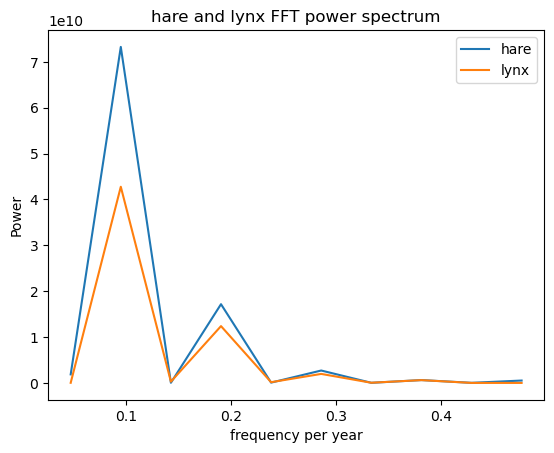

In [20]:
data = np.loadtxt('populations.txt')
year = data[:,0]
hare = data[:,1]
lynx = data[:,2]

N = len(year)
dt = 1

# remove mean
hare_d = hare - np.mean(hare)
lynx_d = lynx - np.mean(lynx)

# FFT
hare_fft = np.fft.fft(hare_d)
lynx_fft = np.fft.fft(lynx_d)
freq = np.fft.fftfreq(N,dt)

# use only positive frequecies
mask = freq > 0
freq_pos = freq[mask]
hare_power = np.abs(hare_fft[mask])**2
lynx_power = np.abs(lynx_fft[mask])**2

# plot
plt.figure()
plt.plot(freq_pos, hare_power, label="hare")
plt.plot(freq_pos, lynx_power, label="lynx")
plt.xlabel("frequency per year")
plt.ylabel("Power")
plt.legend()
plt.title("hare and lynx FFT power spectrum")
plt.show()

**FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

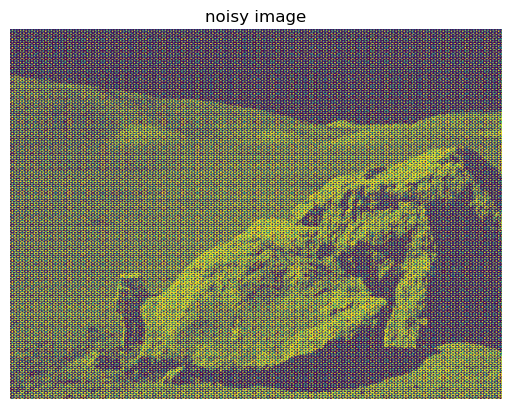

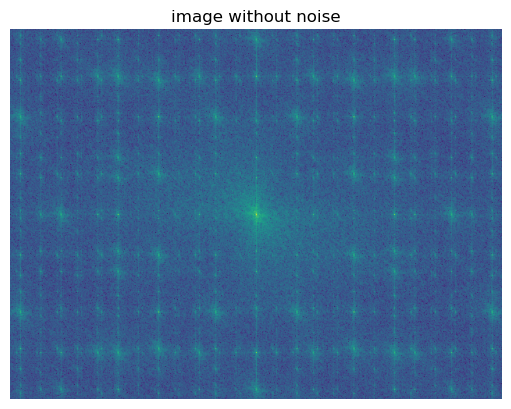

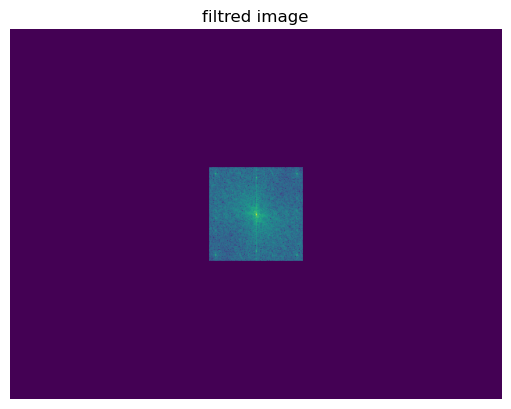

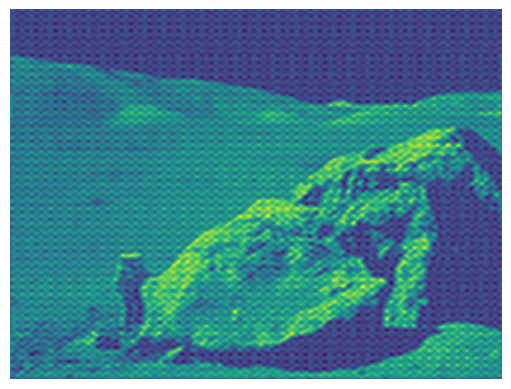

In [21]:
from scipy import fftpack
img = plt.imread("moonlanding.png")
plt.figure()
plt.imshow(img)
plt.title("noisy image")
plt.axis("off")
plt.show()

F = fftpack.fft2(img)
Fshift = fftpack.fftshift(F)
spectrum = np.log( 1+ np.abs(Fshift))

plt.figure()
plt.imshow(spectrum)
plt.title("image without noise")
plt.axis("off")
plt.show()

H,W = img.shape
keep = 60

F_filt = Fshift.copy()
F_filt[:H//2-keep, :] = 0
F_filt[H//2+keep:, :] = 0
F_filt[:, :W//2-keep] = 0
F_filt[:, W//2+keep:] = 0

plt.figure()
plt.imshow(np.log(1 + np.abs(F_filt)))
plt.title("filtred image")
plt.axis("off")
plt.show()

# inverse FFT to reconstruct cleaned image
F_ishift = fftpack.ifftshift(F_filt)
img_clean = fftpack.ifft2(F_ishift)
img_clean = np.real(img_clean)

plt.figure()
plt.imshow(img_clean)
plt.axis("off")
plt.show()

### Monte Carlo

**Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

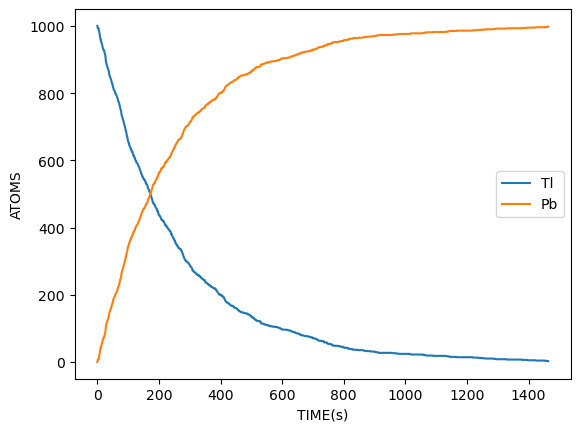

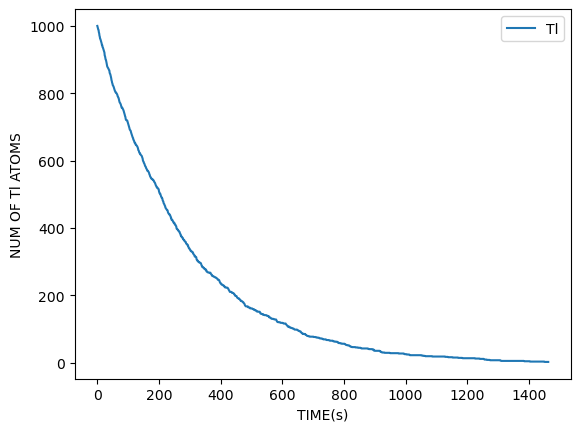

In [27]:
rng = np.random.default_rng(0)
N0 = 1000; tau = 3.052*60; dt = 1
p = 1 - 2**(-dt/tau)                  # decay prob per second
Tl, Pb = [N0], [0]
for _ in range(int(8*tau)):
    d = rng.binomial(Tl[-1], p)       # remember: binomial = how many decay this step
    Tl.append(Tl[-1] - d); Pb.append(Pb[-1] + d)
plt.plot(Tl, label="Tl"); plt.plot(Pb, label="Pb"); plt.xlabel("TIME(s)"); plt.ylabel("ATOMS"); plt.legend(); plt.show()

# inverse-transform the decay times directly
t_decay = -tau*np.log2(rng.random(N0))             # sample from the decay pdf
t = np.arange(int(8*tau))
alive = N0 - np.searchsorted(np.sort(t_decay), t)  # count not-yet-decayed
plt.plot(t, alive, label="Tl");plt.xlabel("TIME(s)"); plt.ylabel("NUM OF Tl ATOMS"); plt.legend(); plt.show()

**Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [30]:
rng = np.random.default_rng(0)
Z=79; e=1.602e-19; eps0=8.854e-12; a0=5.29e-11; E=7.7e6*e
sigma = a0/100
k = Z*e**2 / (2*np.pi*eps0*E)         # critical impact parameter (bounce if b<k)
N = 1_000_000
x = rng.normal(0, sigma, N); y = rng.normal(0, sigma, N)
b = np.sqrt(x**2 + y**2)
print("bounce-back fraction:", np.mean(b < k))

bounce-back fraction: 0.00153


**Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [31]:
f = lambda x: np.sin(1/(x*(2-x)))**2
rng = np.random.default_rng(0); n = 1_000_000; W = 2

x = rng.uniform(0, 2, n); fx = f(x)                       # mean value
I_mv = W*fx.mean(); err_mv = W*fx.std()/np.sqrt(n)

x = rng.uniform(0, 2, n); yh = rng.uniform(0, 1, n)       # hit/miss
hit = yh < f(x); I_hm = W*hit.mean()
err_hm = W*np.sqrt(hit.mean()*(1-hit.mean())/n)
print(f"mean value: {I_mv:.4f} +/- {err_mv:.4f}")
print(f"hit/miss : {I_hm:.4f} +/- {err_hm:.4f}   (mean value error is smaller)")

mean value: 1.4508 +/- 0.0005
hit/miss : 1.4515 +/- 0.0009   (mean value error is smaller)


**Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere


In [34]:
rng = np.random.default_rng(0)
def sphere_vol(d, n=1_000_000):
    pts = rng.uniform(-1, 1, (n, d))
    inside = (pts**2).sum(axis=1) <= 1
    return 2**d * inside.mean()        # remember: box volume = 2^d
print("2-D (≈π):", sphere_vol(2))
print("10-D     :", sphere_vol(10))

2-D (≈π): 3.141576
10-D     : 2.4832


**Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [35]:
rng = np.random.default_rng(0); N = 1_000_000
# weight w(x)=1/sqrt(x); sample x=u^2  ->  integral = mean( 2/(e^x+1) )
x = rng.uniform(0, 1, N)**2
print("I =", np.mean(2/(np.exp(x) + 1)))

I = 0.8388294049772481
